In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS  

df = pd.read_csv('24_25_survey.csv')
df.head()

,Timestamp,First and Last Name (entry for gift card raffle),What is your Class Status?,How many semesters have you lived on campus at Grand View?,Are you currently 21 or older,Do you participate on a Grand View athletic team?,Which Residence Hall did you live in during the fall semester?,What floor did you live on during the fall semester?,Please read the following statements regarding you fall semester RA and rate them. [It is easy to get in contact with my RA],Please read the following statements regarding you fall semester RA and rate them. [I am comfortable talking with my RA],...,Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to lead others because I have lived on campus],Please read the following statements regarding the outcome of living on campus and rate them. [I am better able to take responsibility for my actions because I have lived on campus],Please read the following statements regarding the outcome of living on campus and rate them. [Living on campus had a positive impact on my academic success],Please read the following statements regarding the outcome of living on campus and rate them. [Living on campus has created a sense of belonging at Grand View University],What are the main benefits of living on campus?,What do you enjoy most about living on campus?,What do you dislike about living on campus?,How would you rate your overall satisfaction in regards to living on campus?,Please provide any additional feedback on the Housing Sign-up Process,"Please type your name below to be entered into a gift card drawing for a chance to win a gift card to Target, Krispy Kreme, Taco Bell, and more! There are 5 chances to win!"
0,3/27/2025 14:35:10,Scott Pengelly,Senior,1-2 semesters,Yes,Yes,L Apartments,4th floor,Neutral,Neutral,...,Neutral,Neutral,Neutral,Neutral,No benefits to living on campus,NaN,NaN,Dissatisfied,NaN,Scott Pengelly
1,3/27/2025 14:37:01,Carley Janssen,Sophomore,3-4 semesters,No,Yes,Hull Apartments,1st floor,Strongly Agree,Strongly Agree,...,Neutral,Neutral,Neutral,Neutral,"Proximity to classes, Live within a community ...",NaN,NaN,Satisfied,NaN,Carley Janssen
2,3/27/2025 14:37:02,Adelynne Peterson,Junior,3-4 semesters,No,No,Hull Suites,4th floor,Agree,Agree,...,Strongly agree,Strongly agree,Strongly agree,Strongly agree,"Proximity to classes, Live within a community ...",NaN,NaN,Satisfied,NaN,Adelynne Peterson
3,3/27/2025 14:38:25,NaN,Freshman,1-2 semesters,No,Yes,Langrock Suites,2nd floor,Strongly Agree,Strongly Agree,...,Neutral,Neutral,Neutral,Agree,"Proximity to events/activities, On-Campus Livi...",How close it is,Expensive,Satisfied,NaN,Claire Leinen
4,3/27/2025 14:39:04,Riley Mackey,Senior,5+ semesters,Yes,Yes,L Apartments,4th floor,Strongly Agree,Strongly Agree,...,Neutral,Neutral,Disagree,Agree,"Proximity to classes, Proximity to Wellness Ce...",Closeness to everything provided at a college ...,meal plan and the quality/cleanliness of the room,Neutral,NaN,Riley Mackey


In [4]:
!pip install wordcloud


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\isabe_8m\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
#determine the number of rows and columns in the dataset
df.shape

(145, 90)

In [6]:
#determine number of numeric columns
numeric_cols = df.select_dtypes(include="number").shape[1]
numeric_cols

1

In [7]:
#determine number of character columns
character_cols = df.select_dtypes(include="object").shape[1]
character_cols

89

In [8]:
#determien number of factor columns
factor_cols = df.select_dtypes(include="category").shape[1]
factor_cols

0

In [9]:
#number of missing values 
missing_values = df.isnull().sum().sum()
missing_values

np.int64(2075)

In [10]:
missing_by_column = df.isna().sum()
missing_by_column[missing_by_column > 0]

First and Last Name (entry for gift card raffle)                                                                                                                                    9
Please share any additional comments about your experience with your RA or any other RAs.                                                                                          95
Please share any additional comments about your experience with Residence Life staff members, ( HDs, Assc. Director, & Director of Residence Life).                               124
How many Residence Life programs/events did you attend this school year                                                                                                            24
If you attended a Residence Life program/event this year, what did you enjoy most about the event?                                                                                 67
What type of programs would you like to see on campus?                                    

In [11]:
#duplicate records
duplicate_records = df.duplicated().sum()
duplicate_records

np.int64(0)

In [12]:
df.select_dtypes(include="object").isna().sum().sort_values(ascending=False).head(10)

Please provide any additional feedback on the Housing Sign-up Process                                                                                  134
Please provide any additional feedback..2                                                                                                              133
Please provide any additional feedback.1                                                                                                               131
Please provide any additional feedback..1                                                                                                              131
Please provide any additional feedback on Grand View residential campus culture.                                                                       127
Please provide any additional feedback on GV dining.                                                                                                   127
Please share any additional suggestions for how Residence Life could i

In [13]:
df.columns

Index(['Timestamp', 'First and Last Name (entry for gift card raffle)',
       'What is your Class Status?',
       'How many semesters have you lived on campus at Grand View?',
       'Are you currently 21 or older',
       'Do you participate on a Grand View athletic team?',
       'Which Residence Hall did you live in during the fall semester?',
       'What floor did you live on during the fall semester?',
       'Please read the following statements regarding you fall semester RA and rate them. [It is easy to get in contact with my RA]',
       'Please read the following statements regarding you fall semester RA and rate them. [I am comfortable talking with my RA]',
       'Please read the following statements regarding you fall semester RA and rate them. [My RA has tried to get to know me]',
       'Please read the following statements regarding you fall semester RA and rate them. [My RA has helped me get to know other people]',
       'Please read the following statements regard

Starting visualizations


In [14]:
likert_order = [
    "Strongly agree",
    "Agree",
    "Neutral",
    "Disagree",
    "Strongly disagree"
]

def plot_likert_bar(df, column, title):
    counts = (
        df[column]
        .dropna()
        .value_counts()
        .reindex(likert_order)
    )
    
    plt.figure()
    counts.plot(kind="bar", color = "pink", edgecolor="black")
    plt.title(title, fontweight="bold")
    plt.xlabel("Response (1-5)")
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45)
    plt.show()


In [24]:
likert_order = [
    "Very satisfied",
    "Satisfied",
    "Neutral",
    "Dissatisfied",
    "Very Dissatisfied"
]

def plot_likert_bar(df, column, title):
    counts = (
        df[column]
        .dropna()
        .value_counts()
        .reindex(likert_order)
    )
    
    plt.figure()
    counts.plot(kind="bar", color = "pink", edgecolor="black")
    plt.title(title, fontweight="bold")
    plt.xlabel("Response (1-5)")
    plt.ylabel("Number of Students")
    plt.xticks(rotation=45)
    plt.show()


In [ ]:
df[+]

In [16]:
df[safety_column].unique()

array(['Neutral', 'Agree', 'Disagree', 'Strongly disagree',
       'Strongly agree'], dtype=object)

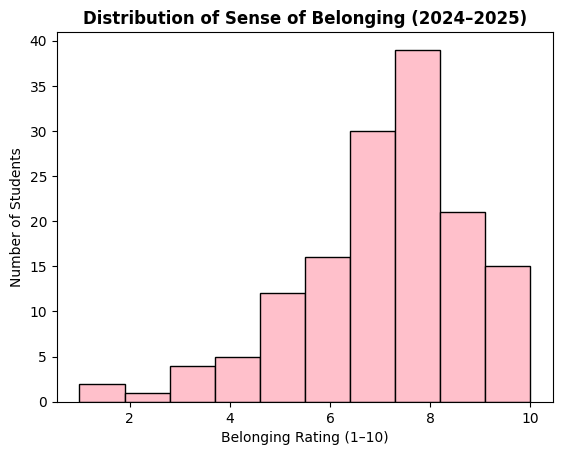

In [17]:
#graph 1, sense of belonging on 1-10 scale
belonging_column = "On a scale of 1-10 how would you rate your sense of belonging/connection to Grand View University"


plt.figure()
df[belonging_column].plot(kind="hist", bins=10, color = "pink", edgecolor="black")
plt.title("Distribution of Sense of Belonging (2024–2025)", fontweight="bold")
plt.xlabel("Belonging Rating (1–10)")
plt.ylabel("Number of Students")
plt.show()

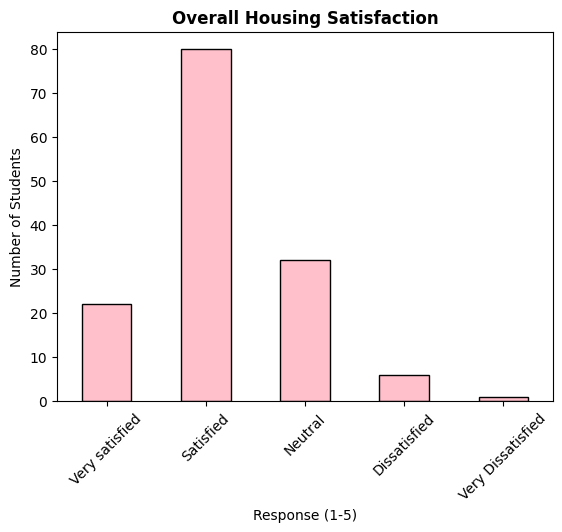

In [18]:
#graph 2, housing satisfaction

plot_likert_bar(
    df,
   "How would you rate your overall satisfaction in regards to living on campus?",
    "Overall Housing Satisfaction"
)

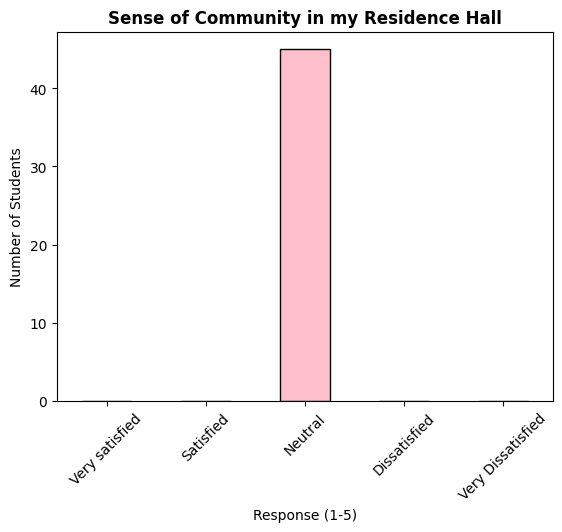

In [25]:
#graph 3, sense of community in each hall

plot_likert_bar(
    df,
    "Please read the following statements regarding the community on campus and rate them. [I feel a strong sense of community among the people living in my residence hall]",
    "Sense of Community in my Residence Hall"
)

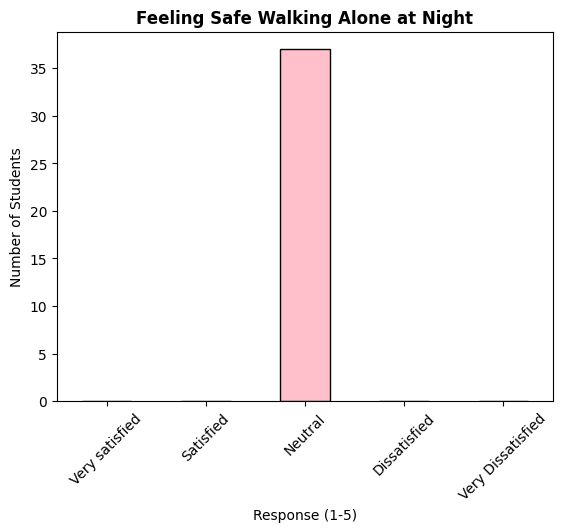

In [20]:
#graph 4, safety at night

plot_likert_bar(
    df,
    "Please read the following statements regarding safety and rate them. [I feel safe walking alone on campus at night]",
    "Feeling Safe Walking Alone at Night"
)

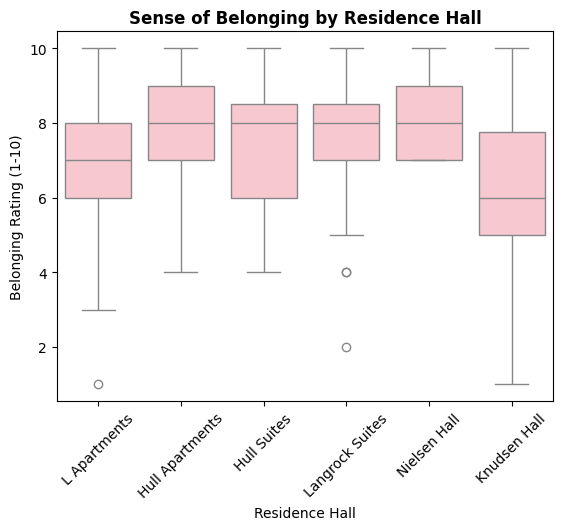

In [21]:
#graph 5,box plot, belonging by residence hall
residence_hall_column = "Which Residence Hall did you live in during the fall semester?"

plt.figure()
sns.boxplot(data=df, x=residence_hall_column, y=belonging_column, color="pink")
plt.title("Sense of Belonging by Residence Hall", fontweight="bold")
plt.xlabel("Residence Hall")
plt.ylabel("Belonging Rating (1-10)")
plt.xticks(rotation = 45)
plt.show()

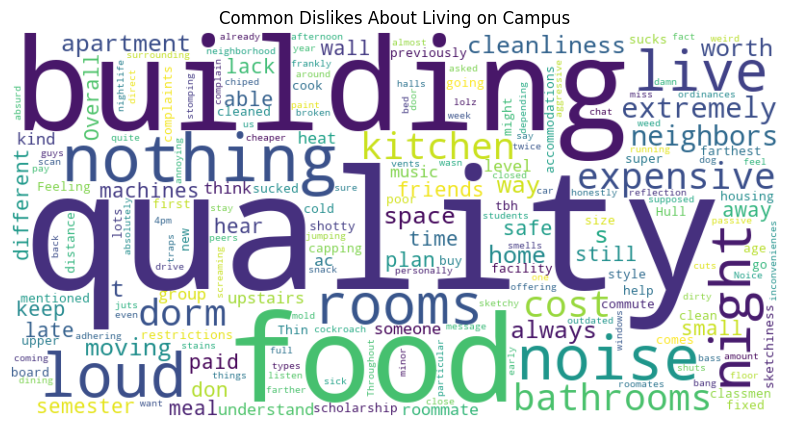

In [22]:
#graph 6, word cloud, dislikes about living on campus
dislikes_column = "What do you dislike about living on campus?"

# Combine all text responses into one string.
text = " ".join(df[dislikes_column].dropna().astype(str))

# Define stopwords to exclude common words that don't add much meaning to the word cloud.
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["living", "campus", "like", "dislike", "people", "residence", 
                         "hall", "dorms", "dormitory", "options", "sometimes", "much", "lot", "really", 
                         "usually", "schedule", "yet", "room", "general", "ridiculous", "odd", "used", 
                         "random", "motivation", "many", "parking", "WiFi", "laundry"])

# Generates the word cloud.
word_cloud = WordCloud(width = 800, height = 400, background_color = "white", stopwords=custom_stopwords).generate(text)

# Displays the word cloud.
plt.figure(figsize=(10,5),)
plt.imshow(word_cloud, interpolation = 'bilinear')
plt.axis("off")
plt.title("Common Dislikes About Living on Campus")
plt.show()

In [26]:
# Column names used often (copied exactly from df.columns)
belonging_column = "On a scale of 1-10 how would you rate your sense of belonging/connection to Grand View University"
residence_hall_column = "Which Residence Hall did you live in during the fall semester?"
community_column = "Please read the following statements regarding the community on campus and rate them. [I feel a strong sense of community among the people living in my residence hall]"
safety_column = "Please read the following statements regarding safety and rate them. [I feel safe walking alone on campus at night]"

# Descriptive statistics for sense of belonging (optional / sanity check)
print("\n=== Descriptive Statistics: Sense of Belonging ===")

belonging_data = df[belonging_column].dropna()

print(f"Mean: {belonging_data.mean():.2f}")
print(f"Median: {belonging_data.median():.2f}")
print(f"Mode: {belonging_data.mode().iloc[0]:.2f}")
print(f"Standard Deviation: {belonging_data.std():.2f}")
print(f"Minimum: {belonging_data.min():.2f}")
print(f"Maximum: {belonging_data.max():.2f}")


=== Descriptive Statistics: Sense of Belonging ===
Mean: 7.26
Median: 8.00
Mode: 8.00
Standard Deviation: 1.90
Minimum: 1.00
Maximum: 10.00


## Comparing the two years

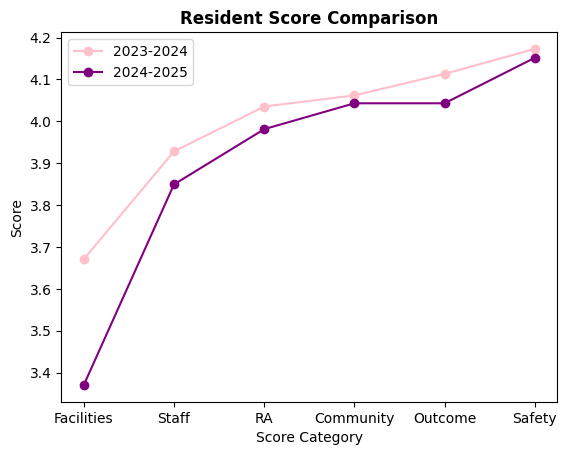

In [8]:
#score categories
import matplotlib.pyplot as plt

items = ["Facilities", "Staff", "RA", "Community", "Outcome", "Safety"]

#scores for each year
scores_23_24 = [3.670992, 3.928197, 4.035377, 4.061995, 4.113208, 4.172956]
scores_24_25 = [3.370443, 3.849425, 3.981281, 4.043103, 4.043103, 4.151724]

plt.plot(items, scores_23_24, marker='o', label='2023-2024', color='pink')
plt.plot(items, scores_24_25, marker='o', label='2024-2025', color='purple')

plt.title('Resident Score Comparison', fontweight="bold")
plt.xlabel('Score Category')
plt.ylabel('Score')

plt.legend()
plt.show()